# Notebook 22. Objective Coastal-Box Metrics and Provisional Regime Labels

This notebook starts the **simpler, physically focused classification** requested after the EOF/clustering work became hard to interpret for the main science question.

The goal here is **not** to build a final manual label set yet. The goal is to:

- define one primary **Sea-of-Japan coastal strip** polygon and keep the existing **JPCZ polygon**
- compute the four raw event-level means for all 201 events:
  - JPCZ-polygon mean `850 hPa q×(-ω)` moisture-flux proxy
  - coastal-strip mean `850 hPa q×(-ω)` moisture-flux proxy
  - JPCZ-polygon mean `925 hPa` signed divergence
  - coastal-strip mean `925 hPa` signed divergence
- test **candidate thresholds** objectively
- assign **provisional regime labels** using only those raw means
- show low-level composites for the provisional offshore-JPCZ and coastal-interaction groups
- keep the old cleaned cluster labels only as **reference columns at the end**, not as the main method

Important note:

- This notebook keeps the raw means in their original sign convention.
- `925 hPa` divergence stays as **signed divergence**, so **more negative values still mean stronger convergence**.
- Real zeros are included in the means; only missing/NaN cells are excluded.


In [1]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = os.environ.get("JPCZ_CATALOG_BRANCH", "codex/notebook16-pcolormesh")
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = False
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

def clone_repo_branch():
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )

def sync_repo_branch():
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", "-B", BRANCH, f"origin/{BRANCH}"], check=True)


if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    clone_repo_branch()
else:
    print("Using existing repo clone:", REPO_DIR)

try:
    sync_repo_branch()
except subprocess.CalledProcessError:
    print("Existing clone could not switch branches cleanly. Re-cloning target branch.")
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
    clone_repo_branch()
    sync_repo_branch()

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

active_branch = subprocess.run(["git", "-C", REPO_DIR, "branch", "--show-current"], text=True, capture_output=True, check=True).stdout.strip()
print("Working directory:", os.getcwd())
print("Runtime repo branch:", active_branch)


Mounted at /content/drive
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs

Cloning into '/content/JPCZcatalog'...

Working directory: /content/JPCZcatalog
Runtime repo branch: codex/notebook16-pcolormesh


In [2]:
from pathlib import Path
import shutil

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import JPCZ_POLYGON_VERTICES, OBJECTIVE_SUBTYPE_DOMAIN
from jpcz_catalog.detect import prepare_detection_geometry
from jpcz_catalog.masks import build_coslat_weights

CLEANED_RUN_EXPORT_DIR = Path("outputs/verification/objective_subtype_low_level_cleaned_sensitivity")
EOF_EXPORT_DIR = Path("outputs/verification/objective_subtype_eof_analysis")
OBJECTIVE_EXPORT_DIR = Path("outputs/verification/objective_coastal_box_regimes")
OBJECTIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_coastal_box_regime_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_CLUSTERED_EVENTS_PATH = CLEANED_RUN_EXPORT_DIR / "clustered_events_cleaned_low_level_k2_k3_k4.csv"
LOW_LEVEL_STACK_PATH = EOF_EXPORT_DIR / "cleaned_low_level_eof_event_fields.nc"

PRIMARY_CLUSTER_COLUMN = "cleaned_cluster_ward_2"
SECONDARY_CLUSTER_COLUMN = "cleaned_cluster_ward_3"

METRIC_FIELDS = [
    "vertical_moisture_flux_proxy_850_peak",
    "divergence_925_peak",
]
REFERENCE_FIELDS = [
    "z850_anomaly_min_tminus12_to_tplus12",
]
COMPOSITE_FIELDS = METRIC_FIELDS
PLOT_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN

# First-pass coastal wedge polygon for the Sea-of-Japan-facing coast.
# The offshore edge is a simple slanted cutoff, while the return edge
# follows the coastline more closely. This is intentionally editable and
# should be refined if the manual review indicates a mismatch.
COASTAL_STRIP_VERTICES = (
    (133.05, 35.55),
    (136.05, 35.55),
    (139.55, 39.00),
    (139.55, 42.55),
)

COASTAL_QFLUX_SPLIT_QUANTILES = (0.60, 0.65, 0.70, 0.75, 0.80)
POLYGON_QFLUX_MIN_QUANTILES = (0.55, 0.60, 0.65, 0.70)
POLYGON_DIV_MAX_QUANTILES = (0.20, 0.25, 0.30, 0.35)
COASTAL_DIV_MAX_QUANTILES = (0.20, 0.25, 0.30, 0.35)

DEFAULT_COASTAL_QFLUX_SPLIT_Q = 0.75
DEFAULT_POLYGON_QFLUX_MIN_Q = 0.60
DEFAULT_POLYGON_DIV_MAX_Q = 0.25
DEFAULT_COASTAL_DIV_MAX_Q = 0.25

# Keep the actual rule simple. Set any of these to a number to test an explicit
# threshold directly; leave as None to seed the starting value from the event
# distribution using the default quantiles above.
MANUAL_POLYGON_QFLUX_MIN_THRESHOLD = None
MANUAL_COASTAL_QFLUX_SPLIT_THRESHOLD = None
MANUAL_POLYGON_DIV_MAX_THRESHOLD = None
MANUAL_COASTAL_DIV_MAX_THRESHOLD = None

FIELD_DISPLAY_NAMES = {
    "vertical_moisture_flux_proxy_850_peak": "850 hPa vertical moisture-flux proxy at event peak (Russian coastal exclusion)",
    "divergence_925_peak": "925 hPa signed divergence at event peak (Russian coastal exclusion)",
    "z850_anomaly_min_tminus12_to_tplus12": "850 hPa z anomaly minimum over t-12/t0/t+12 (Russian coastal exclusion)",
}
SHORT_FIELD_DISPLAY_NAMES = {
    "vertical_moisture_flux_proxy_850_peak": "850 hPa q×(-ω) proxy",
    "divergence_925_peak": "925 hPa signed divergence",
    "z850_anomaly_min_tminus12_to_tplus12": "z850 anomaly",
}
FIELD_UNITS = {
    "vertical_moisture_flux_proxy_850_peak": "1e-3 Pa s^-1",
    "divergence_925_peak": "1e-5 s^-1",
    "z850_anomaly_min_tminus12_to_tplus12": "gpm",
}
FIELD_CMAPS = {
    "vertical_moisture_flux_proxy_850_peak": "BrBG",
    "divergence_925_peak": "RdBu_r",
    "z850_anomaly_min_tminus12_to_tplus12": "RdBu_r",
}
LABEL_COLORS = {
    "offshore_jpcz_core": "#1b9e77",
    "coastal_interaction": "#d95f02",
    "mixed_transition": "#7570b3",
    "weak_or_unclear": "#7f7f7f",
}

EVENT_METRICS_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_event_metrics.csv"
THRESHOLD_TABLE_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_default_thresholds.csv"
THRESHOLD_SENSITIVITY_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_threshold_sensitivity.csv"
LABEL_COUNT_SUMMARY_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_label_counts.csv"
OBJECTIVE_K2_CROSSTAB_PATH = OBJECTIVE_EXPORT_DIR / "objective_vs_cleaned_k2_counts.csv"
OBJECTIVE_K3_CROSSTAB_PATH = OBJECTIVE_EXPORT_DIR / "objective_vs_cleaned_k3_counts.csv"
GROUP_COMPOSITES_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_group_composites.nc"
GROUP_SAMPLE_COUNT_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_group_sample_counts.csv"
GROUP_BOX_SUMMARY_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_group_box_means.csv"
PLOT_INVENTORY_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_plot_inventory.csv"
PLOT_LEVEL_SUMMARY_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_plot_level_summary.csv"
PAIRWISE_SWITCH_SUMMARY_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_pairwise_switch_summary.csv"
SCHEME_LABEL_COUNTS_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_scheme_label_counts.csv"
WEAK_TRANSITION_SUMMARY_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_weak_transition_summary.csv"
CROSSTAB_A_VS_B_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_crosstab_A_vs_B.csv"
CROSSTAB_A_VS_C_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_crosstab_A_vs_C.csv"
CROSSTAB_B_VS_C_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_crosstab_B_vs_C.csv"


def maybe_copy_to_drive(path: Path, *, verbose: bool = True):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return None
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        if verbose:
            print("Copied to Drive:", drive_path)
        return drive_path
    return None



def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive cache:", drive_path)
    return True



def load_cached_dataset(path: Path):
    if not path.exists():
        return None
    with xr.open_dataset(path) as ds:
        return ds.load()



def size_rank_descriptor(rank: int, total: int) -> str:
    if rank == 1:
        return "largest subgroup"
    if rank == total:
        return "smallest subgroup"
    return f"size rank {rank} of {total}"



def build_cluster_labels_from_counts(cluster_counts: pd.Series | dict[int, int]):
    counts_dict = {int(cluster_id): int(n_events) for cluster_id, n_events in dict(cluster_counts).items()}
    ranked = sorted(counts_dict.items(), key=lambda item: (-item[1], item[0]))
    rank_lookup = {cluster_id: rank for rank, (cluster_id, _) in enumerate(ranked, start=1)}
    total = len(ranked)
    label_lookup = {}
    rows = []
    for cluster_id, n_events in sorted(counts_dict.items()):
        descriptor = size_rank_descriptor(rank_lookup[cluster_id], total)
        label_lookup[cluster_id] = f"Cluster {cluster_id}: n={n_events} ({descriptor})"
        rows.append(
            {
                "cluster_id": cluster_id,
                "n_events": n_events,
                "cluster_label": label_lookup[cluster_id],
                "size_rank": rank_lookup[cluster_id],
                "size_descriptor": descriptor,
            }
        )
    return label_lookup, pd.DataFrame(rows)



def lat_weighted_field_mean(field: xr.DataArray, weight_field: xr.DataArray) -> xr.DataArray:
    valid = xr.apply_ufunc(np.isfinite, field)
    weighted_field = field.where(valid, 0.0) * weight_field.where(valid, 0.0)
    denominator = weight_field.where(valid, 0.0).sum(dim=("latitude", "longitude"))
    numerator = weighted_field.sum(dim=("latitude", "longitude"))
    return xr.where(denominator > 0.0, numerator / denominator, np.nan)



def coordinate_edges(coord_values: np.ndarray) -> np.ndarray:
    coord_values = np.asarray(coord_values, dtype=float)
    if coord_values.ndim != 1:
        raise ValueError("Expected a 1D coordinate array when building pcolormesh edges")
    if coord_values.size == 1:
        half_step = 0.125
        return np.array([coord_values[0] - half_step, coord_values[0] + half_step], dtype=float)
    diffs = np.diff(coord_values)
    edges = np.empty(coord_values.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (coord_values[:-1] + coord_values[1:])
    edges[0] = coord_values[0] - 0.5 * diffs[0]
    edges[-1] = coord_values[-1] + 0.5 * diffs[-1]
    return edges



def draw_scalar_pcolormesh(ax, field: xr.DataArray, *, cmap_name: str, levels: np.ndarray, extend: str = "both"):
    lon_edges = coordinate_edges(field.longitude.values)
    lat_edges = coordinate_edges(field.latitude.values)
    n_level_bins = max(len(levels) - 1, 1)
    n_extend_bins = {"neither": 0, "min": 1, "max": 1, "both": 2}.get(extend, 0)
    cmap = plt.get_cmap(cmap_name).resampled(n_level_bins + n_extend_bins)
    norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, clip=False, extend=extend)
    return ax.pcolormesh(
        lon_edges,
        lat_edges,
        field.values,
        cmap=cmap,
        norm=norm,
        shading="flat",
        transform=ccrs.PlateCarree(),
        linewidth=0.0,
        antialiased=False,
        snap=True,
    )



def add_map_features(ax, domain, *, title: str):
    ax.set_extent([domain.lon_min, domain.lon_max, domain.lat_min, domain.lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", linewidth=0.9)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.add_feature(cfeature.LAND, facecolor="#f2f2f2", alpha=0.6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.25, alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title, fontsize=11)
    return gl



def overlay_polygon(ax, vertices, *, color: str, linewidth: float = 2.0, linestyle: str = "-"):
    lon_vals = [vertex[0] for vertex in vertices] + [vertices[0][0]]
    lat_vals = [vertex[1] for vertex in vertices] + [vertices[0][1]]
    ax.plot(lon_vals, lat_vals, color=color, linewidth=linewidth, linestyle=linestyle, transform=ccrs.PlateCarree())



def finite_field_values(*fields: xr.DataArray) -> np.ndarray:
    arrays = []
    for field in fields:
        values = np.asarray(field.values, dtype=float)
        finite = values[np.isfinite(values)]
        if finite.size > 0:
            arrays.append(finite)
    if not arrays:
        return np.array([0.0])
    return np.concatenate(arrays)



def robust_abs_limit(values: np.ndarray, *, upper_q: float = 0.99) -> float:
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return 1.0
    return float(np.nanquantile(np.abs(finite), upper_q))



def rounded_limit(limit: float, step: float, *, minimum: float) -> float:
    return max(minimum, step * np.ceil(max(limit, 0.0) / step))



def build_composite_levels(field_name: str, offshore_field: xr.DataArray, coastal_field: xr.DataArray, diff_field: xr.DataArray) -> np.ndarray:
    values = finite_field_values(offshore_field, coastal_field, diff_field)
    if field_name == "divergence_925_peak":
        step = 1.0
        limit = rounded_limit(robust_abs_limit(values, upper_q=0.99), step, minimum=5.0)
        return np.arange(-limit, limit + step * 0.5, step)
    if field_name == "vertical_moisture_flux_proxy_850_peak":
        step = 0.05
        limit = rounded_limit(robust_abs_limit(values, upper_q=0.99), step, minimum=0.60)
        return np.arange(-limit, limit + step * 0.5, step)
    step = 10.0
    limit = rounded_limit(robust_abs_limit(values, upper_q=0.99), step, minimum=80.0)
    return np.arange(-limit, limit + step * 0.5, step)



def summarize_level_range(field_name: str, offshore_field: xr.DataArray, coastal_field: xr.DataArray, diff_field: xr.DataArray, levels: np.ndarray) -> dict:
    values = finite_field_values(offshore_field, coastal_field, diff_field)
    return {
        "field": field_name,
        "data_min": float(np.min(values)),
        "data_max": float(np.max(values)),
        "level_min": float(levels[0]),
        "level_max": float(levels[-1]),
        "level_step": float(levels[1] - levels[0]) if len(levels) > 1 else float("nan"),
        "n_bins": int(max(len(levels) - 1, 0)),
    }



def mean_dataset_over_events(ds: xr.Dataset, event_indices: list[int]) -> xr.Dataset:
    subset = ds.sel(event_index=event_indices).sortby("event_index")
    return subset.mean(dim="event_index", skipna=True)



def count_dataset_over_events(ds: xr.Dataset, event_indices: list[int]) -> xr.Dataset:
    subset = ds.sel(event_index=event_indices).sortby("event_index")
    rows = {}
    for field_name, field in subset.data_vars.items():
        rows[field_name] = xr.apply_ufunc(np.isfinite, field).sum(dim="event_index")
    return xr.Dataset(rows)



def assign_objective_labels(
    metrics_df: pd.DataFrame,
    *,
    polygon_qflux_min: float,
    polygon_div_max: float,
    coastal_qflux_split: float,
    coastal_div_max: float,
) -> pd.DataFrame:
    labeled_df = metrics_df.copy()
    offshore_mask = (
        np.isfinite(labeled_df["polygon_qflux_850_mean"])
        & np.isfinite(labeled_df["polygon_div_925_mean"])
        & np.isfinite(labeled_df["coastal_qflux_850_mean"])
        & (labeled_df["polygon_qflux_850_mean"] >= polygon_qflux_min)
        & (labeled_df["polygon_div_925_mean"] <= polygon_div_max)
        & (labeled_df["coastal_qflux_850_mean"] < coastal_qflux_split)
    )
    coastal_mask = (
        np.isfinite(labeled_df["coastal_qflux_850_mean"])
        & np.isfinite(labeled_df["coastal_div_925_mean"])
        & (labeled_df["coastal_qflux_850_mean"] >= coastal_qflux_split)
        & (labeled_df["coastal_div_925_mean"] <= coastal_div_max)
    )
    labels = np.full(len(labeled_df), "weak_or_unclear", dtype=object)
    labels[offshore_mask.values] = "offshore_jpcz_core"
    labels[coastal_mask.values] = "coastal_interaction"
    labels[(offshore_mask & coastal_mask).values] = "mixed_transition"
    labeled_df["offshore_rule_pass"] = offshore_mask.astype(bool)
    labeled_df["coastal_rule_pass"] = coastal_mask.astype(bool)
    labeled_df["objective_regime_label"] = labels
    return labeled_df



def summarize_label_counts(labeled_df: pd.DataFrame) -> pd.DataFrame:
    counts = labeled_df["objective_regime_label"].value_counts(dropna=False).rename_axis("objective_regime_label").reset_index(name="n_events")
    counts["fraction_of_201"] = (counts["n_events"] / len(labeled_df)).round(3)
    return counts



def plot_region_definition(domain, *, polygon_vertices, coastal_vertices):
    fig, ax = plt.subplots(figsize=(8.2, 6.0), subplot_kw={"projection": ccrs.PlateCarree()})
    add_map_features(ax, domain, title="Objective regions for the simplified regime method")
    overlay_polygon(ax, polygon_vertices, color="#1f78b4", linewidth=2.4)
    overlay_polygon(ax, coastal_vertices, color="#d95f02", linewidth=2.4)
    ax.text(129.2, 41.5, "JPCZ polygon", color="#1f78b4", fontsize=9.5, transform=ccrs.PlateCarree())
    ax.text(132.2, 35.2, "Coastal strip", color="#d95f02", fontsize=9.5, transform=ccrs.PlateCarree())
    fig.tight_layout()
    return fig



def plot_metric_distribution_grid(metrics_df: pd.DataFrame, threshold_lookup: dict):
    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0))
    panels = [
        ("polygon_qflux_850_mean", "Polygon mean 850 hPa q×(-ω)", threshold_lookup["polygon_qflux_min"]),
        ("coastal_qflux_850_mean", "Coastal-strip mean 850 hPa q×(-ω)", threshold_lookup["coastal_qflux_split"]),
        ("polygon_div_925_mean", "Polygon mean 925 hPa divergence", threshold_lookup["polygon_div_max"]),
        ("coastal_div_925_mean", "Coastal-strip mean 925 hPa divergence", threshold_lookup["coastal_div_max"]),
    ]
    for ax, (column, title, threshold) in zip(axes.flat, panels):
        values = metrics_df[column].to_numpy(dtype=float)
        finite = values[np.isfinite(values)]
        ax.hist(finite, bins=22, color="#bdbdbd", edgecolor="white")
        ax.axvline(threshold, color="#d95f02", linestyle="--", linewidth=2)
        ax.set_title(title)
        ax.set_xlabel(column)
        ax.set_ylabel("Event count")
    fig.tight_layout()
    return fig



def plot_metric_scatter_grid(metrics_df: pd.DataFrame, threshold_lookup: dict):
    fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.6))
    label_order = ["offshore_jpcz_core", "coastal_interaction", "mixed_transition", "weak_or_unclear"]

    for label in label_order:
        subset = metrics_df.loc[metrics_df["objective_regime_label"] == label]
        axes[0].scatter(
            subset["coastal_qflux_850_mean"],
            subset["polygon_qflux_850_mean"],
            s=28,
            alpha=0.8,
            color=LABEL_COLORS[label],
            label=label,
        )
        axes[1].scatter(
            subset["coastal_div_925_mean"],
            subset["polygon_div_925_mean"],
            s=28,
            alpha=0.8,
            color=LABEL_COLORS[label],
            label=label,
        )

    axes[0].axvline(threshold_lookup["coastal_qflux_split"], color="#d95f02", linestyle="--", linewidth=1.8)
    axes[0].axhline(threshold_lookup["polygon_qflux_min"], color="#1b9e77", linestyle="--", linewidth=1.8)
    axes[0].set_title("Moisture-flux regime space")
    axes[0].set_xlabel("Coastal-strip mean 850 hPa q×(-ω)")
    axes[0].set_ylabel("JPCZ-polygon mean 850 hPa q×(-ω)")

    axes[1].axvline(threshold_lookup["coastal_div_max"], color="#d95f02", linestyle="--", linewidth=1.8)
    axes[1].axhline(threshold_lookup["polygon_div_max"], color="#1b9e77", linestyle="--", linewidth=1.8)
    axes[1].set_title("Divergence regime space")
    axes[1].set_xlabel("Coastal-strip mean 925 hPa divergence")
    axes[1].set_ylabel("JPCZ-polygon mean 925 hPa divergence")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    return fig



def plot_regime_triptych(offshore_ds: xr.Dataset, coastal_ds: xr.Dataset, diff_ds: xr.Dataset, field_name: str, domain, *, levels: np.ndarray | None = None):
    offshore_field = offshore_ds[field_name]
    coastal_field = coastal_ds[field_name]
    diff_field = diff_ds[field_name]
    if levels is None:
        levels = build_composite_levels(field_name, offshore_field, coastal_field, diff_field)
    cmap_name = FIELD_CMAPS.get(field_name, "RdBu_r")
    fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.8), subplot_kw={"projection": ccrs.PlateCarree()})
    panel_specs = [
        ("Offshore JPCZ", offshore_field),
        ("Coastal interaction", coastal_field),
        ("Coastal - Offshore", diff_field),
    ]
    cf_last = None
    for ax, (panel_title, field) in zip(axes, panel_specs):
        cf = draw_scalar_pcolormesh(ax, field, cmap_name=cmap_name, levels=levels, extend="both")
        cf_last = cf
        add_map_features(ax, domain, title=panel_title)
        overlay_polygon(ax, JPCZ_POLYGON_VERTICES, color="#1f78b4", linewidth=1.5)
        overlay_polygon(ax, COASTAL_STRIP_VERTICES, color="#d95f02", linewidth=1.5)
    fig.suptitle(FIELD_DISPLAY_NAMES[field_name], fontsize=12.5, y=0.97)
    fig.subplots_adjust(top=0.84, bottom=0.24, left=0.05, right=0.98, wspace=0.08)
    cax = fig.add_axes([0.18, 0.10, 0.64, 0.04])
    cbar = fig.colorbar(cf_last, cax=cax, orientation="horizontal")
    cbar.set_label(f"{SHORT_FIELD_DISPLAY_NAMES[field_name]} [{FIELD_UNITS[field_name]}]", labelpad=4)
    return fig





/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


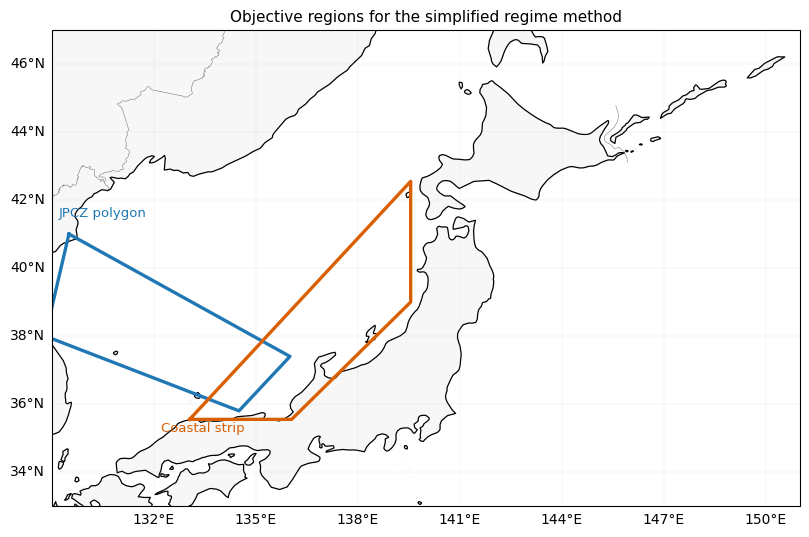

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_region_definition.png
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_plot_inventory.csv
Saved Notebook 22 region-definition plot


,plot_kind,field,local_path,drive_path
0,region_definition,coastal_box_vs_polygon,outputs/verification/objective_coastal_box_reg...,/content/drive/MyDrive/JPCZcatalog_outputs/obj...


In [3]:
required_globals = [
    "plot_region_definition",
    "maybe_copy_to_drive",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 22 helper/config cell before the region-definition cell. "
        f"Missing globals: {missing_globals}"
    )

plot_inventory_rows = []
fig_regions = plot_region_definition(
    PLOT_DOMAIN,
    polygon_vertices=JPCZ_POLYGON_VERTICES,
    coastal_vertices=COASTAL_STRIP_VERTICES,
)
region_plot_path = PLOT_DIR / "objective_coastal_box_region_definition.png"
fig_regions.savefig(region_plot_path, dpi=160, bbox_inches="tight")
plt.show()
maybe_copy_to_drive(region_plot_path)
plot_inventory_rows.append(
    {
        "plot_kind": "region_definition",
        "field": "coastal_box_vs_polygon",
        "local_path": str(region_plot_path),
        "drive_path": str(Path(DRIVE_OUTPUT_DIR) / region_plot_path.name),
    }
)
plot_inventory_df = pd.DataFrame(plot_inventory_rows)
plot_inventory_df.to_csv(PLOT_INVENTORY_PATH, index=False)
maybe_copy_to_drive(PLOT_INVENTORY_PATH)
print("Saved Notebook 22 region-definition plot")
display(plot_inventory_df)




In [4]:
paths_to_restore = [CLEANED_CLUSTERED_EVENTS_PATH, LOW_LEVEL_STACK_PATH]
for path in paths_to_restore:
    if not path.exists():
        restore_from_drive_cache(path)

if not CLEANED_CLUSTERED_EVENTS_PATH.exists():
    raise RuntimeError("Run Notebook 15 first so the cleaned clustered event table exists.")
if not LOW_LEVEL_STACK_PATH.exists():
    raise RuntimeError("Run Notebook 17 first so the cleaned low-level event stack exists.")

clustered_df = pd.read_csv(CLEANED_CLUSTERED_EVENTS_PATH)
clustered_df = add_japan_local_time_columns(clustered_df)
required_columns = [PRIMARY_CLUSTER_COLUMN, SECONDARY_CLUSTER_COLUMN, "event_peak"]
missing_columns = [column for column in required_columns if column not in clustered_df.columns]
if missing_columns:
    raise RuntimeError(f"Missing required columns in the cleaned clustered event table: {missing_columns}")

low_level_stack_ds = load_cached_dataset(LOW_LEVEL_STACK_PATH)
if low_level_stack_ds is None:
    raise RuntimeError("Unable to restore the cleaned low-level event stack.")
missing_fields = [field for field in METRIC_FIELDS + REFERENCE_FIELDS if field not in low_level_stack_ds.data_vars]
if missing_fields:
    raise RuntimeError(f"The cleaned low-level stack is missing required fields: {missing_fields}")

geometry_polygon = prepare_detection_geometry(
    low_level_stack_ds.longitude,
    low_level_stack_ds.latitude,
    JPCZ_POLYGON_VERTICES,
)
geometry_coastal_full = prepare_detection_geometry(
    low_level_stack_ds.longitude,
    low_level_stack_ds.latitude,
    COASTAL_STRIP_VERTICES,
)
polygon_mask = geometry_polygon.polygon_mask.astype(bool)
coastal_full_mask = geometry_coastal_full.polygon_mask.astype(bool)
overlap_mask = xr.DataArray(
    polygon_mask.values & coastal_full_mask.values,
    coords=polygon_mask.coords,
    dims=polygon_mask.dims,
    name="polygon_coastal_overlap_mask",
)
polygon_only_mask = xr.DataArray(
    polygon_mask.values & (~coastal_full_mask.values),
    coords=polygon_mask.coords,
    dims=polygon_mask.dims,
    name="polygon_only_mask",
)
coastal_only_mask = xr.DataArray(
    coastal_full_mask.values & (~polygon_mask.values),
    coords=polygon_mask.coords,
    dims=polygon_mask.dims,
    name="coastal_only_mask",
)
weights_polygon = geometry_polygon.weights
weights_coastal_full = geometry_coastal_full.weights
weights_overlap = build_coslat_weights(
    low_level_stack_ds.latitude,
    low_level_stack_ds.longitude,
    mask=overlap_mask,
)
weights_polygon_only = build_coslat_weights(
    low_level_stack_ds.latitude,
    low_level_stack_ds.longitude,
    mask=polygon_only_mask,
)
weights_coastal_only = build_coslat_weights(
    low_level_stack_ds.latitude,
    low_level_stack_ds.longitude,
    mask=coastal_only_mask,
)

def build_event_metric_frame(shared_df: pd.DataFrame, *, polygon_qflux_column: str, polygon_div_column: str, coastal_qflux_column: str, coastal_div_column: str) -> pd.DataFrame:
    metric_df = shared_df.copy()
    metric_df["polygon_qflux_850_mean"] = metric_df[polygon_qflux_column]
    metric_df["polygon_div_925_mean"] = metric_df[polygon_div_column]
    metric_df["coastal_qflux_850_mean"] = metric_df[coastal_qflux_column]
    metric_df["coastal_div_925_mean"] = metric_df[coastal_div_column]
    return metric_df

def build_scheme_outputs(metric_df: pd.DataFrame, *, scheme_name: str, polygon_region_label: str, coastal_region_label: str):
    metric_spec_rows = [
        {
            "threshold_key": "polygon_qflux_min",
            "metric_column": "polygon_qflux_850_mean",
            "metric_label": f"{polygon_region_label} mean 850 hPa q×(-ω)",
            "units": FIELD_UNITS["vertical_moisture_flux_proxy_850_peak"],
            "tested_quantiles": POLYGON_QFLUX_MIN_QUANTILES,
            "default_quantile": DEFAULT_POLYGON_QFLUX_MIN_Q,
            "manual_threshold": MANUAL_POLYGON_QFLUX_MIN_THRESHOLD,
            "rule_role": f"minimum {polygon_region_label} moisture-flux support for offshore JPCZ",
        },
        {
            "threshold_key": "coastal_qflux_split",
            "metric_column": "coastal_qflux_850_mean",
            "metric_label": f"{coastal_region_label} mean 850 hPa q×(-ω)",
            "units": FIELD_UNITS["vertical_moisture_flux_proxy_850_peak"],
            "tested_quantiles": COASTAL_QFLUX_SPLIT_QUANTILES,
            "default_quantile": DEFAULT_COASTAL_QFLUX_SPLIT_Q,
            "manual_threshold": MANUAL_COASTAL_QFLUX_SPLIT_THRESHOLD,
            "rule_role": f"{coastal_region_label} moisture-flux split",
        },
        {
            "threshold_key": "polygon_div_max",
            "metric_column": "polygon_div_925_mean",
            "metric_label": f"{polygon_region_label} mean 925 hPa divergence",
            "units": FIELD_UNITS["divergence_925_peak"],
            "tested_quantiles": POLYGON_DIV_MAX_QUANTILES,
            "default_quantile": DEFAULT_POLYGON_DIV_MAX_Q,
            "manual_threshold": MANUAL_POLYGON_DIV_MAX_THRESHOLD,
            "rule_role": f"maximum {polygon_region_label} divergence allowed for offshore JPCZ (more negative = stronger convergence)",
        },
        {
            "threshold_key": "coastal_div_max",
            "metric_column": "coastal_div_925_mean",
            "metric_label": f"{coastal_region_label} mean 925 hPa divergence",
            "units": FIELD_UNITS["divergence_925_peak"],
            "tested_quantiles": COASTAL_DIV_MAX_QUANTILES,
            "default_quantile": DEFAULT_COASTAL_DIV_MAX_Q,
            "manual_threshold": MANUAL_COASTAL_DIV_MAX_THRESHOLD,
            "rule_role": f"maximum {coastal_region_label} divergence allowed for coastal-interaction regime (more negative = stronger convergence)",
        },
    ]

    quartile_rows = []
    threshold_summary_rows = []
    seeded_threshold_lookup = {}
    default_threshold_lookup = {}
    quantile_value_lookup = {}

    for spec in metric_spec_rows:
        series = metric_df[spec["metric_column"]].to_numpy(dtype=float)
        q25 = float(np.nanquantile(series, 0.25))
        median = float(np.nanquantile(series, 0.50))
        q75 = float(np.nanquantile(series, 0.75))
        quartile_rows.append(
            {
                "metric": spec["metric_column"],
                "metric_label": spec["metric_label"],
                "units": spec["units"],
                "q25": q25,
                "median": median,
                "q75": q75,
            }
        )

        candidate_quantiles = [float(q) for q in spec["tested_quantiles"]]
        candidate_values = [float(np.nanquantile(series, q)) for q in candidate_quantiles]
        quantile_value_lookup[spec["threshold_key"]] = dict(zip(candidate_quantiles, candidate_values))

        seeded_value = float(np.nanquantile(series, spec["default_quantile"]))
        seeded_threshold_lookup[spec["threshold_key"]] = seeded_value
        threshold_value = float(spec["manual_threshold"]) if spec["manual_threshold"] is not None else seeded_value
        default_threshold_lookup[spec["threshold_key"]] = threshold_value

        threshold_summary_rows.append(
            {
                "threshold_key": spec["threshold_key"],
                "metric": spec["metric_column"],
                "metric_label": spec["metric_label"],
                "units": spec["units"],
                "q25": q25,
                "median": median,
                "q75": q75,
                "default_quantile": float(spec["default_quantile"]),
                "default_threshold_value": threshold_value,
                "threshold_source": "manual" if spec["manual_threshold"] is not None else f"seeded from q={spec['default_quantile']:.2f}",
                "tested_quantiles": ", ".join(f"{q:.2f}" for q in candidate_quantiles),
                "tested_threshold_values": ", ".join(f"{value:.3f}" for value in candidate_values),
                "rule_role": spec["rule_role"],
            }
        )

    quartile_reference_df = pd.DataFrame(quartile_rows)
    quartile_reference_df[["q25", "median", "q75"]] = quartile_reference_df[["q25", "median", "q75"]].round(6)

    threshold_summary_df = pd.DataFrame(threshold_summary_rows)
    threshold_summary_df[["q25", "median", "q75", "default_quantile", "default_threshold_value"]] = threshold_summary_df[["q25", "median", "q75", "default_quantile", "default_threshold_value"]].round(6)

    sensitivity_rows = []
    for polygon_qflux_q in POLYGON_QFLUX_MIN_QUANTILES:
        polygon_qflux_value = quantile_value_lookup["polygon_qflux_min"][float(polygon_qflux_q)]
        for coastal_qflux_q in COASTAL_QFLUX_SPLIT_QUANTILES:
            coastal_qflux_value = quantile_value_lookup["coastal_qflux_split"][float(coastal_qflux_q)]
            for polygon_div_q in POLYGON_DIV_MAX_QUANTILES:
                polygon_div_value = quantile_value_lookup["polygon_div_max"][float(polygon_div_q)]
                for coastal_div_q in COASTAL_DIV_MAX_QUANTILES:
                    coastal_div_value = quantile_value_lookup["coastal_div_max"][float(coastal_div_q)]
                    candidate_labeled_df = assign_objective_labels(
                        metric_df,
                        polygon_qflux_min=polygon_qflux_value,
                        polygon_div_max=polygon_div_value,
                        coastal_qflux_split=coastal_qflux_value,
                        coastal_div_max=coastal_div_value,
                    )
                    counts = candidate_labeled_df["objective_regime_label"].value_counts()
                    offshore_n = int(counts.get("offshore_jpcz_core", 0))
                    coastal_n = int(counts.get("coastal_interaction", 0))
                    mixed_n = int(counts.get("mixed_transition", 0))
                    weak_n = int(counts.get("weak_or_unclear", 0))
                    sorted_n = offshore_n + coastal_n + mixed_n
                    sensitivity_rows.append(
                        {
                            "scheme_name": scheme_name,
                            "is_default_setting": bool(
                                np.isclose(float(polygon_qflux_q), DEFAULT_POLYGON_QFLUX_MIN_Q)
                                and np.isclose(float(coastal_qflux_q), DEFAULT_COASTAL_QFLUX_SPLIT_Q)
                                and np.isclose(float(polygon_div_q), DEFAULT_POLYGON_DIV_MAX_Q)
                                and np.isclose(float(coastal_div_q), DEFAULT_COASTAL_DIV_MAX_Q)
                            ),
                            "polygon_qflux_min_quantile": float(polygon_qflux_q),
                            "polygon_qflux_min_value": polygon_qflux_value,
                            "coastal_qflux_split_quantile": float(coastal_qflux_q),
                            "coastal_qflux_split_value": coastal_qflux_value,
                            "polygon_div_max_quantile": float(polygon_div_q),
                            "polygon_div_max_value": polygon_div_value,
                            "coastal_div_max_quantile": float(coastal_div_q),
                            "coastal_div_max_value": coastal_div_value,
                            "offshore_jpcz_core_n": offshore_n,
                            "coastal_interaction_n": coastal_n,
                            "mixed_transition_n": mixed_n,
                            "weak_or_unclear_n": weak_n,
                            "sorted_event_count": sorted_n,
                            "sorted_fraction_of_201": round(sorted_n / len(metric_df), 3),
                            "labels_summary": f"{offshore_n} offshore | {coastal_n} coastal | {mixed_n} mixed | {weak_n} weak",
                        }
                    )

    threshold_sensitivity_df = pd.DataFrame(sensitivity_rows)
    threshold_sensitivity_df[[
        "polygon_qflux_min_quantile",
        "polygon_qflux_min_value",
        "coastal_qflux_split_quantile",
        "coastal_qflux_split_value",
        "polygon_div_max_quantile",
        "polygon_div_max_value",
        "coastal_div_max_quantile",
        "coastal_div_max_value",
        "sorted_fraction_of_201",
    ]] = threshold_sensitivity_df[[
        "polygon_qflux_min_quantile",
        "polygon_qflux_min_value",
        "coastal_qflux_split_quantile",
        "coastal_qflux_split_value",
        "polygon_div_max_quantile",
        "polygon_div_max_value",
        "coastal_div_max_quantile",
        "coastal_div_max_value",
        "sorted_fraction_of_201",
    ]].round(6)
    threshold_sensitivity_df = threshold_sensitivity_df.sort_values(
        ["is_default_setting", "sorted_event_count", "weak_or_unclear_n", "mixed_transition_n", "coastal_interaction_n"],
        ascending=[False, False, True, True, False],
    ).reset_index(drop=True)

    threshold_sensitivity_display_df = threshold_sensitivity_df.rename(
        columns={
            "is_default_setting": "default_setting",
            "polygon_qflux_min_quantile": "polygon_qflux_q",
            "polygon_qflux_min_value": f"polygon_qflux_min [{FIELD_UNITS['vertical_moisture_flux_proxy_850_peak']}]",
            "coastal_qflux_split_quantile": "coastal_qflux_q",
            "coastal_qflux_split_value": f"coastal_qflux_split [{FIELD_UNITS['vertical_moisture_flux_proxy_850_peak']}]",
            "polygon_div_max_quantile": "polygon_div_q",
            "polygon_div_max_value": f"polygon_div_max [{FIELD_UNITS['divergence_925_peak']}]",
            "coastal_div_max_quantile": "coastal_div_q",
            "coastal_div_max_value": f"coastal_div_max [{FIELD_UNITS['divergence_925_peak']}]",
            "offshore_jpcz_core_n": "offshore_n",
            "coastal_interaction_n": "coastal_n",
            "mixed_transition_n": "mixed_n",
            "weak_or_unclear_n": "weak_n",
            "sorted_event_count": "sorted_n",
            "sorted_fraction_of_201": "sorted_fraction",
        }
    )[[
        "default_setting",
        "polygon_qflux_q",
        f"polygon_qflux_min [{FIELD_UNITS['vertical_moisture_flux_proxy_850_peak']}]",
        "coastal_qflux_q",
        f"coastal_qflux_split [{FIELD_UNITS['vertical_moisture_flux_proxy_850_peak']}]",
        "polygon_div_q",
        f"polygon_div_max [{FIELD_UNITS['divergence_925_peak']}]",
        "coastal_div_q",
        f"coastal_div_max [{FIELD_UNITS['divergence_925_peak']}]",
        "offshore_n",
        "coastal_n",
        "mixed_n",
        "weak_n",
        "sorted_n",
        "sorted_fraction",
        "labels_summary",
    ]].copy()

    labeled_metrics_df = assign_objective_labels(
        metric_df,
        polygon_qflux_min=default_threshold_lookup["polygon_qflux_min"],
        polygon_div_max=default_threshold_lookup["polygon_div_max"],
        coastal_qflux_split=default_threshold_lookup["coastal_qflux_split"],
        coastal_div_max=default_threshold_lookup["coastal_div_max"],
    )
    label_count_summary_df = summarize_label_counts(labeled_metrics_df)
    objective_vs_k2_counts_df = pd.crosstab(labeled_metrics_df["objective_regime_label"], labeled_metrics_df[PRIMARY_CLUSTER_COLUMN])
    objective_vs_k3_counts_df = pd.crosstab(labeled_metrics_df["objective_regime_label"], labeled_metrics_df[SECONDARY_CLUSTER_COLUMN])
    display_df = labeled_metrics_df[
        [
            "event_index",
            "event_peak",
            "event_peak_jst",
            "polygon_qflux_850_mean",
            "coastal_qflux_850_mean",
            "polygon_div_925_mean",
            "coastal_div_925_mean",
            "objective_regime_label",
            PRIMARY_CLUSTER_COLUMN,
            SECONDARY_CLUSTER_COLUMN,
        ]
    ].copy()
    for column in ["polygon_qflux_850_mean", "coastal_qflux_850_mean", "polygon_div_925_mean", "coastal_div_925_mean"]:
        display_df[column] = display_df[column].round(3)
    return {
        "scheme_name": scheme_name,
        "polygon_region_label": polygon_region_label,
        "coastal_region_label": coastal_region_label,
        "metric_df": metric_df,
        "quartile_reference_df": quartile_reference_df,
        "threshold_summary_df": threshold_summary_df,
        "threshold_sensitivity_df": threshold_sensitivity_df,
        "threshold_sensitivity_display_df": threshold_sensitivity_display_df,
        "default_threshold_lookup": default_threshold_lookup,
        "labeled_metrics_df": labeled_metrics_df,
        "label_count_summary_df": label_count_summary_df,
        "objective_vs_k2_counts_df": objective_vs_k2_counts_df,
        "objective_vs_k3_counts_df": objective_vs_k3_counts_df,
        "display_df": display_df,
    }


shared_metrics_df = pd.DataFrame(
    {
        "event_index": low_level_stack_ds["event_index"].values.astype(int),
        "event_peak": pd.to_datetime(low_level_stack_ds["event_peak"].values),
        PRIMARY_CLUSTER_COLUMN: low_level_stack_ds["cleaned_cluster_k2"].values.astype(int),
        SECONDARY_CLUSTER_COLUMN: low_level_stack_ds["cleaned_cluster_k3"].values.astype(int),
        "polygon_qflux_850_mean": lat_weighted_field_mean(low_level_stack_ds["vertical_moisture_flux_proxy_850_peak"], weights_polygon).values.astype(float),
        "polygon_div_925_mean": lat_weighted_field_mean(low_level_stack_ds["divergence_925_peak"], weights_polygon).values.astype(float),
        "polygon_only_qflux_850_mean": lat_weighted_field_mean(low_level_stack_ds["vertical_moisture_flux_proxy_850_peak"], weights_polygon_only).values.astype(float),
        "polygon_only_div_925_mean": lat_weighted_field_mean(low_level_stack_ds["divergence_925_peak"], weights_polygon_only).values.astype(float),
        "coastal_full_qflux_850_mean": lat_weighted_field_mean(low_level_stack_ds["vertical_moisture_flux_proxy_850_peak"], weights_coastal_full).values.astype(float),
        "coastal_full_div_925_mean": lat_weighted_field_mean(low_level_stack_ds["divergence_925_peak"], weights_coastal_full).values.astype(float),
        "coastal_only_qflux_850_mean": lat_weighted_field_mean(low_level_stack_ds["vertical_moisture_flux_proxy_850_peak"], weights_coastal_only).values.astype(float),
        "coastal_only_div_925_mean": lat_weighted_field_mean(low_level_stack_ds["divergence_925_peak"], weights_coastal_only).values.astype(float),
        "overlap_qflux_850_mean": lat_weighted_field_mean(low_level_stack_ds["vertical_moisture_flux_proxy_850_peak"], weights_overlap).values.astype(float),
        "overlap_div_925_mean": lat_weighted_field_mean(low_level_stack_ds["divergence_925_peak"], weights_overlap).values.astype(float),
    }
)
shared_metrics_df = shared_metrics_df.merge(
    clustered_df[[PRIMARY_CLUSTER_COLUMN, SECONDARY_CLUSTER_COLUMN, "event_peak", "event_peak_jst", "duration_hours"]],
    left_on="event_index",
    right_index=True,
    how="left",
    suffixes=("", "_from_table"),
)
shared_metrics_df = shared_metrics_df.drop(columns=[f"{PRIMARY_CLUSTER_COLUMN}_from_table", f"{SECONDARY_CLUSTER_COLUMN}_from_table"], errors="ignore")
shared_metrics_df = shared_metrics_df.sort_values("event_peak").reset_index(drop=True)

geometry_region_summary_df = pd.DataFrame(
    [
        {"region": "JPCZ polygon", "n_gridcells": int(polygon_mask.sum().values), "weight_sum": float(weights_polygon.sum().values)},
        {"region": "JPCZ polygon minus overlap", "n_gridcells": int(polygon_only_mask.sum().values), "weight_sum": float(weights_polygon_only.sum().values)},
        {"region": "Coastal wedge (full)", "n_gridcells": int(coastal_full_mask.sum().values), "weight_sum": float(weights_coastal_full.sum().values)},
        {"region": "Overlap", "n_gridcells": int(overlap_mask.sum().values), "weight_sum": float(weights_overlap.sum().values)},
        {"region": "Coastal wedge minus overlap", "n_gridcells": int(coastal_only_mask.sum().values), "weight_sum": float(weights_coastal_only.sum().values)},
    ]
)
geometry_region_summary_df[["weight_sum"]] = geometry_region_summary_df[["weight_sum"]].round(3)

print("Notebook 22 shared setup for overlap testing")
print("- The next three calculation cells test: A) polygon minus overlap with full coastal wedge, B) full polygon with coastal wedge minus overlap, and C) both regions kept full with overlap.")
print("\nRegion-mask summary")
display(geometry_region_summary_df)


Restored from Drive cache: /content/drive/MyDrive/JPCZcatalog_outputs/clustered_events_cleaned_low_level_k2_k3_k4.csv
Restored from Drive cache: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_low_level_eof_event_fields.nc
Notebook 22 shared setup for overlap testing
- The next three calculation cells test: A) polygon minus overlap with full coastal wedge, B) full polygon with coastal wedge minus overlap, and C) both regions kept full with overlap.

Region-mask summary


,region,n_gridcells,weight_sum
0,JPCZ polygon,277,217.691
1,JPCZ polygon minus overlap,244,191.269
2,Coastal wedge (full),273,214.057
3,Overlap,33,26.422
4,Coastal wedge minus overlap,240,187.635


In [5]:
required_globals = [
    "shared_metrics_df",
    "build_event_metric_frame",
    "build_scheme_outputs",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 22 shared-setup cell before the coastal_full calculation cell. "
        f"Missing globals: {missing_globals}"
    )

calc_a_metric_df = build_event_metric_frame(
    shared_metrics_df,
    polygon_qflux_column="polygon_only_qflux_850_mean",
    polygon_div_column="polygon_only_div_925_mean",
    coastal_qflux_column="coastal_full_qflux_850_mean",
    coastal_div_column="coastal_full_div_925_mean",
)
calc_a_scheme_outputs = build_scheme_outputs(
    calc_a_metric_df,
    scheme_name="polygon_minus_overlap__coastal_full",
    polygon_region_label="JPCZ polygon minus overlap",
    coastal_region_label="Coastal wedge (full)",
)

labeled_metrics_calc_a_df = calc_a_scheme_outputs["labeled_metrics_df"]
threshold_summary_calc_a_df = calc_a_scheme_outputs["threshold_summary_df"]
quartile_reference_calc_a_df = calc_a_scheme_outputs["quartile_reference_df"]
label_count_calc_a_df = calc_a_scheme_outputs["label_count_summary_df"]
objective_vs_k2_calc_a_df = calc_a_scheme_outputs["objective_vs_k2_counts_df"]
objective_vs_k3_calc_a_df = calc_a_scheme_outputs["objective_vs_k3_counts_df"]
labeled_metrics_calc_a_display_df = calc_a_scheme_outputs["display_df"]

print("Calculation A: JPCZ polygon minus overlap plus full coastal wedge")
print("- The coastal wedge keeps the overlap. The JPCZ polygon mean excludes the overlap cells.")
print("\nTested threshold table")
display(threshold_summary_calc_a_df)
print("\nQuartile reference table")
display(quartile_reference_calc_a_df)
print("\nObjective regime counts")
display(label_count_calc_a_df)
print("\nFirst 15 labeled events")
display(labeled_metrics_calc_a_display_df.head(15))



Calculation A: JPCZ polygon minus overlap plus full coastal wedge
- The coastal wedge keeps the overlap. The JPCZ polygon mean excludes the overlap cells.

Tested threshold table


,threshold_key,metric,metric_label,units,q25,median,q75,default_quantile,default_threshold_value,threshold_source,tested_quantiles,tested_threshold_values,rule_role
0,polygon_qflux_min,polygon_qflux_850_mean,JPCZ polygon minus overlap mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.349319,0.534015,0.777072,0.60,0.625685,seeded from q=0.60,"0.55, 0.60, 0.65, 0.70","0.567, 0.626, 0.651, 0.689",minimum JPCZ polygon minus overlap moisture-fl...
1,coastal_qflux_split,coastal_qflux_850_mean,Coastal wedge (full) mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.591359,0.936743,1.574025,0.75,1.574025,seeded from q=0.75,"0.60, 0.65, 0.70, 0.75, 0.80","1.084, 1.215, 1.401, 1.574, 1.718",Coastal wedge (full) moisture-flux split
2,polygon_div_max,polygon_div_925_mean,JPCZ polygon minus overlap mean 925 hPa diverg...,1e-5 s^-1,-2.577491,-1.965561,-1.415166,0.25,-2.577491,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-2.665, -2.577, -2.450, -2.347",maximum JPCZ polygon minus overlap divergence ...
3,coastal_div_max,coastal_div_925_mean,Coastal wedge (full) mean 925 hPa divergence,1e-5 s^-1,-3.108041,-1.951807,-1.061237,0.25,-3.108041,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-3.349, -3.108, -2.962, -2.800",maximum Coastal wedge (full) divergence allowe...



Quartile reference table


,metric,metric_label,units,q25,median,q75
0,polygon_qflux_850_mean,JPCZ polygon minus overlap mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.349319,0.534015,0.777072
1,coastal_qflux_850_mean,Coastal wedge (full) mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.591359,0.936743,1.574025
2,polygon_div_925_mean,JPCZ polygon minus overlap mean 925 hPa diverg...,1e-5 s^-1,-2.577491,-1.965561,-1.415166
3,coastal_div_925_mean,Coastal wedge (full) mean 925 hPa divergence,1e-5 s^-1,-3.108041,-1.951807,-1.061237



Objective regime counts


,objective_regime_label,n_events,fraction_of_201
0,weak_or_unclear,140,0.697
1,coastal_interaction,33,0.164
2,offshore_jpcz_core,28,0.139



First 15 labeled events


,event_index,event_peak,event_peak_jst,polygon_qflux_850_mean,coastal_qflux_850_mean,polygon_div_925_mean,coastal_div_925_mean,objective_regime_label,cleaned_cluster_ward_2,cleaned_cluster_ward_3
0,0,2000-01-05 23:00:00,2000-01-06 08:00:00,2.341,0.414,-2.762,-0.289,offshore_jpcz_core,1,3
1,1,2000-01-13 11:00:00,2000-01-13 20:00:00,0.856,0.707,-1.624,-0.765,weak_or_unclear,1,3
2,2,2000-01-20 04:00:00,2000-01-20 13:00:00,0.512,0.949,-2.508,-3.599,weak_or_unclear,1,3
3,3,2000-02-08 00:00:00,2000-02-08 09:00:00,1.096,0.956,-4.837,-2.800,offshore_jpcz_core,1,3
4,4,2000-02-14 22:00:00,2000-02-15 07:00:00,0.352,0.816,-2.717,-2.132,weak_or_unclear,1,1
5,5,2000-02-17 09:00:00,2000-02-17 18:00:00,0.236,0.339,-1.353,-1.743,weak_or_unclear,1,1
6,6,2000-02-27 23:00:00,2000-02-28 08:00:00,0.406,1.278,-2.063,-3.548,weak_or_unclear,1,3
7,7,2000-11-10 13:00:00,2000-11-10 22:00:00,0.869,2.516,-1.745,-3.222,coastal_interaction,1,1
8,8,2000-11-17 10:00:00,2000-11-17 19:00:00,0.062,0.944,-0.857,-1.378,weak_or_unclear,1,3
9,9,2000-11-20 05:00:00,2000-11-20 14:00:00,2.330,2.311,-1.252,-1.621,weak_or_unclear,2,2


In [6]:
required_globals = [
    "shared_metrics_df",
    "build_event_metric_frame",
    "build_scheme_outputs",
    "weights_coastal_only",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 22 shared-setup cell before the coastal_only calculation cell. "
        f"Missing globals: {missing_globals}"
    )

calc_b_metric_df = build_event_metric_frame(
    shared_metrics_df,
    polygon_qflux_column="polygon_qflux_850_mean",
    polygon_div_column="polygon_div_925_mean",
    coastal_qflux_column="coastal_only_qflux_850_mean",
    coastal_div_column="coastal_only_div_925_mean",
)
calc_b_scheme_outputs = build_scheme_outputs(
    calc_b_metric_df,
    scheme_name="polygon_full__coastal_minus_overlap",
    polygon_region_label="JPCZ polygon",
    coastal_region_label="Coastal wedge minus JPCZ overlap",
)

labeled_metrics_calc_b_df = calc_b_scheme_outputs["labeled_metrics_df"]
threshold_summary_calc_b_df = calc_b_scheme_outputs["threshold_summary_df"]
threshold_sensitivity_calc_b_df = calc_b_scheme_outputs["threshold_sensitivity_df"]
threshold_sensitivity_calc_b_display_df = calc_b_scheme_outputs["threshold_sensitivity_display_df"]
quartile_reference_calc_b_df = calc_b_scheme_outputs["quartile_reference_df"]
label_count_calc_b_df = calc_b_scheme_outputs["label_count_summary_df"]
objective_vs_k2_calc_b_df = calc_b_scheme_outputs["objective_vs_k2_counts_df"]
objective_vs_k3_calc_b_df = calc_b_scheme_outputs["objective_vs_k3_counts_df"]
labeled_metrics_calc_b_display_df = calc_b_scheme_outputs["display_df"]

print("Calculation B: full JPCZ polygon plus coastal wedge minus overlap")
print("- The JPCZ polygon keeps the overlap. The coastal-wedge mean excludes the overlap cells.")
print("\nThreshold origin table (quartiles plus active threshold)")
display(threshold_summary_calc_b_df)
print("\nThreshold sweep table for Calculation B")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(threshold_sensitivity_calc_b_display_df)
print("\nQuartile reference table")
display(quartile_reference_calc_b_df)
print("\nObjective regime counts")
display(label_count_calc_b_df)
print("\nFirst 15 labeled events")
display(labeled_metrics_calc_b_display_df.head(15))


Calculation B: full JPCZ polygon plus coastal wedge minus overlap
- The JPCZ polygon keeps the overlap. The coastal-wedge mean excludes the overlap cells.

Threshold origin table (quartiles plus active threshold)


,threshold_key,metric,metric_label,units,q25,median,q75,default_quantile,default_threshold_value,threshold_source,tested_quantiles,tested_threshold_values,rule_role
0,polygon_qflux_min,polygon_qflux_850_mean,JPCZ polygon mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.443535,0.591391,0.921394,0.60,0.684752,seeded from q=0.60,"0.55, 0.60, 0.65, 0.70","0.648, 0.685, 0.751, 0.868",minimum JPCZ polygon moisture-flux support for...
1,coastal_qflux_split,coastal_qflux_850_mean,Coastal wedge minus JPCZ overlap mean 850 hPa ...,1e-3 Pa s^-1,0.494673,0.914214,1.617480,0.75,1.617480,seeded from q=0.75,"0.60, 0.65, 0.70, 0.75, 0.80","1.061, 1.185, 1.346, 1.617, 1.857",Coastal wedge minus JPCZ overlap moisture-flux...
2,polygon_div_max,polygon_div_925_mean,JPCZ polygon mean 925 hPa divergence,1e-5 s^-1,-2.626144,-2.120996,-1.639784,0.25,-2.626144,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-2.749, -2.626, -2.532, -2.369",maximum JPCZ polygon divergence allowed for of...
3,coastal_div_max,coastal_div_925_mean,Coastal wedge minus JPCZ overlap mean 925 hPa ...,1e-5 s^-1,-3.129825,-1.889082,-0.719244,0.25,-3.129825,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-3.366, -3.130, -2.950, -2.728",maximum Coastal wedge minus JPCZ overlap diver...



Threshold sweep table for Calculation B


,default_setting,polygon_qflux_q,polygon_qflux_min [1e-3 Pa s^-1],coastal_qflux_q,coastal_qflux_split [1e-3 Pa s^-1],polygon_div_q,polygon_div_max [1e-5 s^-1],coastal_div_q,coastal_div_max [1e-5 s^-1],offshore_n,coastal_n,mixed_n,weak_n,sorted_n,sorted_fraction,labels_summary
0,True,0.60,0.684752,0.75,1.617480,0.25,-2.626144,0.25,-3.129825,31,33,0,137,64,0.318,31 offshore | 33 coastal | 0 mixed | 137 weak
1,False,0.55,0.647563,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,29,56,0,116,85,0.423,29 offshore | 56 coastal | 0 mixed | 116 weak
2,False,0.60,0.684752,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,27,56,0,118,83,0.413,27 offshore | 56 coastal | 0 mixed | 118 weak
3,False,0.55,0.647563,0.65,1.184638,0.35,-2.368891,0.35,-2.727745,31,52,0,118,83,0.413,31 offshore | 52 coastal | 0 mixed | 118 weak
4,False,0.55,0.647563,0.60,1.061034,0.30,-2.532481,0.35,-2.727745,26,56,0,119,82,0.408,26 offshore | 56 coastal | 0 mixed | 119 weak
5,False,0.55,0.647563,0.60,1.061034,0.25,-2.626144,0.35,-2.727745,25,56,0,120,81,0.403,25 offshore | 56 coastal | 0 mixed | 120 weak
6,False,0.60,0.684752,0.60,1.061034,0.30,-2.532481,0.35,-2.727745,25,56,0,120,81,0.403,25 offshore | 56 coastal | 0 mixed | 120 weak
7,False,0.65,0.750528,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,25,56,0,120,81,0.403,25 offshore | 56 coastal | 0 mixed | 120 weak
8,False,0.60,0.684752,0.65,1.184638,0.35,-2.368891,0.35,-2.727745,29,52,0,120,81,0.403,29 offshore | 52 coastal | 0 mixed | 120 weak
9,False,0.55,0.647563,0.70,1.345528,0.35,-2.368891,0.35,-2.727745,34,47,0,120,81,0.403,34 offshore | 47 coastal | 0 mixed | 120 weak



Quartile reference table


,metric,metric_label,units,q25,median,q75
0,polygon_qflux_850_mean,JPCZ polygon mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.443535,0.591391,0.921394
1,coastal_qflux_850_mean,Coastal wedge minus JPCZ overlap mean 850 hPa ...,1e-3 Pa s^-1,0.494673,0.914214,1.617480
2,polygon_div_925_mean,JPCZ polygon mean 925 hPa divergence,1e-5 s^-1,-2.626144,-2.120996,-1.639784
3,coastal_div_925_mean,Coastal wedge minus JPCZ overlap mean 925 hPa ...,1e-5 s^-1,-3.129825,-1.889082,-0.719244



Objective regime counts


,objective_regime_label,n_events,fraction_of_201
0,weak_or_unclear,137,0.682
1,coastal_interaction,33,0.164
2,offshore_jpcz_core,31,0.154



First 15 labeled events


,event_index,event_peak,event_peak_jst,polygon_qflux_850_mean,coastal_qflux_850_mean,polygon_div_925_mean,coastal_div_925_mean,objective_regime_label,cleaned_cluster_ward_2,cleaned_cluster_ward_3
0,0,2000-01-05 23:00:00,2000-01-06 08:00:00,2.420,0.051,-2.864,0.178,offshore_jpcz_core,1,3
1,1,2000-01-13 11:00:00,2000-01-13 20:00:00,0.907,0.627,-1.711,-0.543,weak_or_unclear,1,3
2,2,2000-01-20 04:00:00,2000-01-20 13:00:00,0.591,0.920,-2.813,-3.400,weak_or_unclear,1,3
3,3,2000-02-08 00:00:00,2000-02-08 09:00:00,0.985,1.065,-4.287,-3.152,offshore_jpcz_core,1,3
4,4,2000-02-14 22:00:00,2000-02-15 07:00:00,0.340,0.895,-2.447,-2.362,weak_or_unclear,1,1
5,5,2000-02-17 09:00:00,2000-02-17 18:00:00,0.260,0.326,-1.540,-1.580,weak_or_unclear,1,1
6,6,2000-02-27 23:00:00,2000-02-28 08:00:00,0.383,1.428,-1.791,-4.072,weak_or_unclear,1,3
7,7,2000-11-10 13:00:00,2000-11-10 22:00:00,0.936,2.670,-1.867,-3.289,coastal_interaction,1,1
8,8,2000-11-17 10:00:00,2000-11-17 19:00:00,0.458,0.609,-1.324,-0.910,weak_or_unclear,1,3
9,9,2000-11-20 05:00:00,2000-11-20 14:00:00,2.282,2.365,-1.246,-1.679,weak_or_unclear,2,2


In [7]:
required_globals = [
    "shared_metrics_df",
    "build_event_metric_frame",
    "build_scheme_outputs",
    "weights_polygon",
    "weights_coastal_full",
    "labeled_metrics_calc_a_df",
    "labeled_metrics_calc_b_df",
    "label_count_calc_a_df",
    "label_count_calc_b_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run Calculations A and B before the Calculation C / comparison cell. "
        f"Missing globals: {missing_globals}"
    )

calc_c_metric_df = build_event_metric_frame(
    shared_metrics_df,
    polygon_qflux_column="polygon_qflux_850_mean",
    polygon_div_column="polygon_div_925_mean",
    coastal_qflux_column="coastal_full_qflux_850_mean",
    coastal_div_column="coastal_full_div_925_mean",
)
calc_c_scheme_outputs = build_scheme_outputs(
    calc_c_metric_df,
    scheme_name="polygon_full__coastal_full",
    polygon_region_label="JPCZ polygon",
    coastal_region_label="Coastal wedge (full)",
)

labeled_metrics_calc_c_df = calc_c_scheme_outputs["labeled_metrics_df"]
threshold_summary_calc_c_df = calc_c_scheme_outputs["threshold_summary_df"]
threshold_sensitivity_calc_c_df = calc_c_scheme_outputs["threshold_sensitivity_df"]
threshold_sensitivity_calc_c_display_df = calc_c_scheme_outputs["threshold_sensitivity_display_df"]
quartile_reference_calc_c_df = calc_c_scheme_outputs["quartile_reference_df"]
label_count_calc_c_df = calc_c_scheme_outputs["label_count_summary_df"]
objective_vs_k2_calc_c_df = calc_c_scheme_outputs["objective_vs_k2_counts_df"]
objective_vs_k3_calc_c_df = calc_c_scheme_outputs["objective_vs_k3_counts_df"]
labeled_metrics_calc_c_display_df = calc_c_scheme_outputs["display_df"]

# Make Calculation B the active downstream classification by default.
labeled_metrics_df = labeled_metrics_calc_b_df
threshold_summary_df = threshold_summary_calc_b_df
threshold_sensitivity_df = threshold_sensitivity_calc_b_df
threshold_sensitivity_display_df = threshold_sensitivity_calc_b_display_df
quartile_reference_df = quartile_reference_calc_b_df
label_count_summary_df = label_count_calc_b_df
objective_vs_k2_counts_df = objective_vs_k2_calc_b_df
objective_vs_k3_counts_df = objective_vs_k3_calc_b_df
polygon_region_weight_field_active = weights_polygon
polygon_region_label_active = "JPCZ polygon"
coastal_region_weight_field_active = weights_coastal_only
coastal_region_label_active = "Coastal wedge minus JPCZ overlap"

# Save the active outputs to the standard notebook paths.
labeled_metrics_df.to_csv(EVENT_METRICS_PATH, index=False)
threshold_summary_df.to_csv(THRESHOLD_TABLE_PATH, index=False)
threshold_sensitivity_df.to_csv(THRESHOLD_SENSITIVITY_PATH, index=False)
quartile_reference_df.to_csv(OBJECTIVE_EXPORT_DIR / "objective_coastal_box_quartile_reference.csv", index=False)
label_count_summary_df.to_csv(LABEL_COUNT_SUMMARY_PATH, index=False)
objective_vs_k2_counts_df.to_csv(OBJECTIVE_K2_CROSSTAB_PATH)
objective_vs_k3_counts_df.to_csv(OBJECTIVE_K3_CROSSTAB_PATH)
for path in [
    EVENT_METRICS_PATH,
    THRESHOLD_TABLE_PATH,
    THRESHOLD_SENSITIVITY_PATH,
    LABEL_COUNT_SUMMARY_PATH,
    OBJECTIVE_K2_CROSSTAB_PATH,
    OBJECTIVE_K3_CROSSTAB_PATH,
]:
    maybe_copy_to_drive(path)

comparison_df = shared_metrics_df[["event_index", "event_peak", "event_peak_jst", "overlap_qflux_850_mean", "overlap_div_925_mean"]].copy()
comparison_df["calc_a_label"] = labeled_metrics_calc_a_df["objective_regime_label"].values
comparison_df["calc_b_label"] = labeled_metrics_calc_b_df["objective_regime_label"].values
comparison_df["calc_c_label"] = labeled_metrics_calc_c_df["objective_regime_label"].values
comparison_df["A_vs_B_changed"] = comparison_df["calc_a_label"] != comparison_df["calc_b_label"]
comparison_df["A_vs_C_changed"] = comparison_df["calc_a_label"] != comparison_df["calc_c_label"]
comparison_df["B_vs_C_changed"] = comparison_df["calc_b_label"] != comparison_df["calc_c_label"]

pairwise_switch_summary_df = pd.DataFrame(
    [
        {"comparison": "A vs B", "labels_changed": int(comparison_df["A_vs_B_changed"].sum()), "labels_unchanged": int((~comparison_df["A_vs_B_changed"]).sum())},
        {"comparison": "A vs C", "labels_changed": int(comparison_df["A_vs_C_changed"].sum()), "labels_unchanged": int((~comparison_df["A_vs_C_changed"]).sum())},
        {"comparison": "B vs C", "labels_changed": int(comparison_df["B_vs_C_changed"].sum()), "labels_unchanged": int((~comparison_df["B_vs_C_changed"]).sum())},
    ]
)
scheme_label_counts_df = (
    pd.DataFrame(
        {
            "Calculation A": label_count_calc_a_df.set_index("objective_regime_label")["n_events"],
            "Calculation B": label_count_calc_b_df.set_index("objective_regime_label")["n_events"],
            "Calculation C": label_count_calc_c_df.set_index("objective_regime_label")["n_events"],
        }
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)
weak_transition_summary_df = pd.DataFrame(
    [
        {"summary": "weak_or_unclear in Calculation A", "value": int((comparison_df["calc_a_label"] == "weak_or_unclear").sum())},
        {"summary": "weak_or_unclear in Calculation B", "value": int((comparison_df["calc_b_label"] == "weak_or_unclear").sum())},
        {"summary": "weak_or_unclear in Calculation C", "value": int((comparison_df["calc_c_label"] == "weak_or_unclear").sum())},
        {"summary": "A weak_or_unclear -> B sorted", "value": int(((comparison_df["calc_a_label"] == "weak_or_unclear") & (comparison_df["calc_b_label"] != "weak_or_unclear")).sum())},
        {"summary": "A weak_or_unclear -> C sorted", "value": int(((comparison_df["calc_a_label"] == "weak_or_unclear") & (comparison_df["calc_c_label"] != "weak_or_unclear")).sum())},
        {"summary": "B weak_or_unclear -> A sorted", "value": int(((comparison_df["calc_b_label"] == "weak_or_unclear") & (comparison_df["calc_a_label"] != "weak_or_unclear")).sum())},
        {"summary": "B weak_or_unclear -> C sorted", "value": int(((comparison_df["calc_b_label"] == "weak_or_unclear") & (comparison_df["calc_c_label"] != "weak_or_unclear")).sum())},
        {"summary": "C weak_or_unclear -> A sorted", "value": int(((comparison_df["calc_c_label"] == "weak_or_unclear") & (comparison_df["calc_a_label"] != "weak_or_unclear")).sum())},
        {"summary": "C weak_or_unclear -> B sorted", "value": int(((comparison_df["calc_c_label"] == "weak_or_unclear") & (comparison_df["calc_b_label"] != "weak_or_unclear")).sum())},
    ]
)
overlap_metric_summary_df = pd.DataFrame(
    [
        {
            "metric": "overlap_qflux_850_mean",
            "q25": float(np.nanquantile(comparison_df["overlap_qflux_850_mean"].values, 0.25)),
            "median": float(np.nanquantile(comparison_df["overlap_qflux_850_mean"].values, 0.50)),
            "q75": float(np.nanquantile(comparison_df["overlap_qflux_850_mean"].values, 0.75)),
            "max": float(np.nanmax(comparison_df["overlap_qflux_850_mean"].values)),
        },
        {
            "metric": "overlap_div_925_mean",
            "q25": float(np.nanquantile(comparison_df["overlap_div_925_mean"].values, 0.25)),
            "median": float(np.nanquantile(comparison_df["overlap_div_925_mean"].values, 0.50)),
            "q75": float(np.nanquantile(comparison_df["overlap_div_925_mean"].values, 0.75)),
            "max": float(np.nanmax(comparison_df["overlap_div_925_mean"].values)),
        },
    ]
)
overlap_metric_summary_df[["q25", "median", "q75", "max"]] = overlap_metric_summary_df[["q25", "median", "q75", "max"]].round(6)

crosstab_a_vs_b_df = pd.crosstab(comparison_df["calc_a_label"], comparison_df["calc_b_label"])
crosstab_a_vs_c_df = pd.crosstab(comparison_df["calc_a_label"], comparison_df["calc_c_label"])
crosstab_b_vs_c_df = pd.crosstab(comparison_df["calc_b_label"], comparison_df["calc_c_label"])

coastal_shift_b_vs_c_df = comparison_df.loc[
    (comparison_df["calc_b_label"] == "coastal_interaction") & (comparison_df["calc_c_label"] != "coastal_interaction"),
    ["event_index", "event_peak_jst", "overlap_qflux_850_mean", "overlap_div_925_mean", "calc_b_label", "calc_c_label"],
].copy()
coastal_shift_b_vs_c_df[["overlap_qflux_850_mean", "overlap_div_925_mean"]] = coastal_shift_b_vs_c_df[["overlap_qflux_850_mean", "overlap_div_925_mean"]].round(3)

pairwise_switch_summary_df.to_csv(PAIRWISE_SWITCH_SUMMARY_PATH, index=False)
scheme_label_counts_df.to_csv(SCHEME_LABEL_COUNTS_PATH, index=False)
weak_transition_summary_df.to_csv(WEAK_TRANSITION_SUMMARY_PATH, index=False)
crosstab_a_vs_b_df.to_csv(CROSSTAB_A_VS_B_PATH)
crosstab_a_vs_c_df.to_csv(CROSSTAB_A_VS_C_PATH)
crosstab_b_vs_c_df.to_csv(CROSSTAB_B_VS_C_PATH)
for path in [
    PAIRWISE_SWITCH_SUMMARY_PATH,
    SCHEME_LABEL_COUNTS_PATH,
    WEAK_TRANSITION_SUMMARY_PATH,
    CROSSTAB_A_VS_B_PATH,
    CROSSTAB_A_VS_C_PATH,
    CROSSTAB_B_VS_C_PATH,
]:
    maybe_copy_to_drive(path)

print("Calculation C: full JPCZ polygon plus full coastal wedge")
print("- This is the baseline setup where both regions keep the overlap.")
print("- Calculation C is the full-overlap sensitivity check only; Calculation B remains the active downstream scheme.")
print("\nTested threshold table")
display(threshold_summary_calc_c_df)
print("\nQuartile reference table")
display(quartile_reference_calc_c_df)
print("\nObjective regime counts")
display(label_count_calc_c_df)
print("\nFirst 15 labeled events")
display(labeled_metrics_calc_c_display_df.head(15))

print("\nComparison across Calculations A, B, and C")
print("- A = polygon minus overlap plus full coastal wedge")
print("- B = full polygon plus coastal wedge minus overlap")
print("- C = full polygon plus full coastal wedge")
print("\nPairwise label-switch summary")
display(pairwise_switch_summary_df)
print("\nCounts by regime for Calculations A, B, and C")
display(scheme_label_counts_df)
print("\nHow many weak_or_unclear events got sorted")
display(weak_transition_summary_df)
print("\nA versus B label switches")
display(crosstab_a_vs_b_df)
print("\nA versus C label switches")
display(crosstab_a_vs_c_df)
print("\nB versus C label switches")
display(crosstab_b_vs_c_df)
print("\nOverlap-region metric summary")
display(overlap_metric_summary_df)
print("\nEvents that were coastal under Calculation B but not Calculation C")
display(coastal_shift_b_vs_c_df.head(20))


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_event_metrics.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_default_thresholds.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_threshold_sensitivity.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_label_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_vs_cleaned_k2_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_vs_cleaned_k3_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_pairwise_switch_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_scheme_label_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_weak_transition_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_co

,threshold_key,metric,metric_label,units,q25,median,q75,default_quantile,default_threshold_value,threshold_source,tested_quantiles,tested_threshold_values,rule_role
0,polygon_qflux_min,polygon_qflux_850_mean,JPCZ polygon mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.443535,0.591391,0.921394,0.60,0.684752,seeded from q=0.60,"0.55, 0.60, 0.65, 0.70","0.648, 0.685, 0.751, 0.868",minimum JPCZ polygon moisture-flux support for...
1,coastal_qflux_split,coastal_qflux_850_mean,Coastal wedge (full) mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.591359,0.936743,1.574025,0.75,1.574025,seeded from q=0.75,"0.60, 0.65, 0.70, 0.75, 0.80","1.084, 1.215, 1.401, 1.574, 1.718",Coastal wedge (full) moisture-flux split
2,polygon_div_max,polygon_div_925_mean,JPCZ polygon mean 925 hPa divergence,1e-5 s^-1,-2.626144,-2.120996,-1.639784,0.25,-2.626144,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-2.749, -2.626, -2.532, -2.369",maximum JPCZ polygon divergence allowed for of...
3,coastal_div_max,coastal_div_925_mean,Coastal wedge (full) mean 925 hPa divergence,1e-5 s^-1,-3.108041,-1.951807,-1.061237,0.25,-3.108041,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-3.349, -3.108, -2.962, -2.800",maximum Coastal wedge (full) divergence allowe...



Quartile reference table


,metric,metric_label,units,q25,median,q75
0,polygon_qflux_850_mean,JPCZ polygon mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.443535,0.591391,0.921394
1,coastal_qflux_850_mean,Coastal wedge (full) mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.591359,0.936743,1.574025
2,polygon_div_925_mean,JPCZ polygon mean 925 hPa divergence,1e-5 s^-1,-2.626144,-2.120996,-1.639784
3,coastal_div_925_mean,Coastal wedge (full) mean 925 hPa divergence,1e-5 s^-1,-3.108041,-1.951807,-1.061237



Objective regime counts


...

calc_c_label,coastal_interaction,offshore_jpcz_core,weak_or_unclear
calc_b_label,,,
coastal_interaction,28,0,5
offshore_jpcz_core,1,29,1
weak_or_unclear,4,0,133



Overlap-region metric summary


,metric,q25,median,q75,max
0,overlap_qflux_850_mean,0.507913,1.074989,1.961272,13.931598
1,overlap_div_925_mean,-4.595910,-2.840408,-1.403712,4.051815



Events that were coastal under Calculation B but not Calculation C


,event_index,event_peak_jst,overlap_qflux_850_mean,overlap_div_925_mean,calc_b_label,calc_c_label
78,78,2007-11-18 09:00:00,0.521,-0.951,coastal_interaction,weak_or_unclear
82,82,2008-01-23 23:00:00,0.059,0.158,coastal_interaction,weak_or_unclear
93,93,2008-11-29 21:00:00,0.184,-1.024,coastal_interaction,weak_or_unclear
99,99,2009-11-15 02:00:00,0.284,-0.461,coastal_interaction,weak_or_unclear
189,189,2017-12-16 15:00:00,0.254,-0.117,coastal_interaction,weak_or_unclear


In [8]:
required_globals = [
    "labeled_metrics_df",
    "low_level_stack_ds",
    "geometry_polygon",
    "polygon_region_weight_field_active",
    "polygon_region_label_active",
    "coastal_region_weight_field_active",
    "coastal_region_label_active",
    "mean_dataset_over_events",
    "count_dataset_over_events",
    "lat_weighted_field_mean",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 22 metric-table cell before the group-composite cell. "
        f"Missing globals: {missing_globals}"
    )

offshore_event_indices = labeled_metrics_df.loc[labeled_metrics_df["objective_regime_label"] == "offshore_jpcz_core", "event_index"].astype(int).tolist()
coastal_event_indices = labeled_metrics_df.loc[labeled_metrics_df["objective_regime_label"] == "coastal_interaction", "event_index"].astype(int).tolist()
mixed_event_indices = labeled_metrics_df.loc[labeled_metrics_df["objective_regime_label"] == "mixed_transition", "event_index"].astype(int).tolist()
weak_event_indices = labeled_metrics_df.loc[labeled_metrics_df["objective_regime_label"] == "weak_or_unclear", "event_index"].astype(int).tolist()

if len(offshore_event_indices) == 0 or len(coastal_event_indices) == 0:
    raise RuntimeError(
        "The default threshold set did not produce both offshore and coastal groups. "
        "Adjust the tested thresholds in the config/helper cell before building composites."
    )

offshore_ds = mean_dataset_over_events(low_level_stack_ds[COMPOSITE_FIELDS + REFERENCE_FIELDS], offshore_event_indices)
coastal_ds = mean_dataset_over_events(low_level_stack_ds[COMPOSITE_FIELDS + REFERENCE_FIELDS], coastal_event_indices)
diff_ds = coastal_ds - offshore_ds

offshore_counts_ds = count_dataset_over_events(low_level_stack_ds[COMPOSITE_FIELDS + REFERENCE_FIELDS], offshore_event_indices)
coastal_counts_ds = count_dataset_over_events(low_level_stack_ds[COMPOSITE_FIELDS + REFERENCE_FIELDS], coastal_event_indices)

group_composites_ds = xr.merge(
    [
        offshore_ds.expand_dims(group=["offshore_jpcz_core"]),
        coastal_ds.expand_dims(group=["coastal_interaction"]),
        diff_ds.expand_dims(group=["coastal_minus_offshore"]),
    ],
    compat="override",
    join="outer",
)
group_composites_ds.to_netcdf(GROUP_COMPOSITES_PATH)
maybe_copy_to_drive(GROUP_COMPOSITES_PATH)

group_sample_count_rows = []
for group_name, count_ds, n_events in [
    ("offshore_jpcz_core", offshore_counts_ds, len(offshore_event_indices)),
    ("coastal_interaction", coastal_counts_ds, len(coastal_event_indices)),
]:
    for field_name in count_ds.data_vars:
        counts = count_ds[field_name]
        group_sample_count_rows.append(
            {
                "objective_regime_label": group_name,
                "field": field_name,
                "field_label": FIELD_DISPLAY_NAMES[field_name],
                "units": FIELD_UNITS[field_name],
                "n_events_in_group": n_events,
                "min_gridcell_count": int(np.nanmin(counts.values)),
                "median_gridcell_count": float(np.nanmedian(counts.values)),
                "max_gridcell_count": int(np.nanmax(counts.values)),
            }
        )
group_sample_count_df = pd.DataFrame(group_sample_count_rows)
group_sample_count_df.to_csv(GROUP_SAMPLE_COUNT_PATH, index=False)
maybe_copy_to_drive(GROUP_SAMPLE_COUNT_PATH)

group_box_summary_rows = []
for group_name, group_ds in [("offshore_jpcz_core", offshore_ds), ("coastal_interaction", coastal_ds), ("coastal_minus_offshore", diff_ds)]:
    for field_name in COMPOSITE_FIELDS:
        field = group_ds[field_name]
        polygon_mean = float(lat_weighted_field_mean(field, polygon_region_weight_field_active).values)
        coastal_mean = float(lat_weighted_field_mean(field, coastal_region_weight_field_active).values)
        group_box_summary_rows.extend(
            [
                {
                    "objective_regime_label": group_name,
                    "field": field_name,
                    "field_label": FIELD_DISPLAY_NAMES[field_name],
                    "region": polygon_region_label_active,
                    "weighted_mean": polygon_mean,
                },
                {
                    "objective_regime_label": group_name,
                    "field": field_name,
                    "field_label": FIELD_DISPLAY_NAMES[field_name],
                    "region": coastal_region_label_active,
                    "weighted_mean": coastal_mean,
                },
            ]
        )
group_box_summary_df = pd.DataFrame(group_box_summary_rows)
group_box_summary_df["weighted_mean"] = group_box_summary_df["weighted_mean"].round(3)
group_box_summary_df.to_csv(GROUP_BOX_SUMMARY_PATH, index=False)
maybe_copy_to_drive(GROUP_BOX_SUMMARY_PATH)

print("Notebook 22 objective-group counts")
display(pd.DataFrame([
    {"objective_regime_label": "offshore_jpcz_core", "n_events": len(offshore_event_indices)},
    {"objective_regime_label": "coastal_interaction", "n_events": len(coastal_event_indices)},
    {"objective_regime_label": "mixed_transition", "n_events": len(mixed_event_indices)},
    {"objective_regime_label": "weak_or_unclear", "n_events": len(weak_event_indices)},
]))
print("\nObjective-group sample-count summary")
display(group_sample_count_df)
print("\nObjective-group polygon and coastal-strip means")
display(group_box_summary_df)



Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_group_composites.nc
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_group_sample_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_group_box_means.csv
Notebook 22 objective-group counts


,objective_regime_label,n_events
0,offshore_jpcz_core,31
1,coastal_interaction,33
2,mixed_transition,0
3,weak_or_unclear,137



Objective-group sample-count summary


,objective_regime_label,field,field_label,units,n_events_in_group,min_gridcell_count,median_gridcell_count,max_gridcell_count
0,offshore_jpcz_core,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,31,0,31.0,31
1,offshore_jpcz_core,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,31,0,31.0,31
2,offshore_jpcz_core,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,31,0,31.0,31
3,coastal_interaction,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,33,0,33.0,33
4,coastal_interaction,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,33,0,33.0,33
5,coastal_interaction,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,33,0,33.0,33



Objective-group polygon and coastal-strip means


,objective_regime_label,field,field_label,region,weighted_mean
0,offshore_jpcz_core,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,JPCZ polygon,1.254
1,offshore_jpcz_core,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Coastal wedge minus JPCZ overlap,0.677
2,offshore_jpcz_core,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,JPCZ polygon,-3.231
3,offshore_jpcz_core,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,Coastal wedge minus JPCZ overlap,-1.239
4,coastal_interaction,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,JPCZ polygon,0.647
5,coastal_interaction,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Coastal wedge minus JPCZ overlap,2.907
6,coastal_interaction,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,JPCZ polygon,-2.012
7,coastal_interaction,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,Coastal wedge minus JPCZ overlap,-4.730
8,coastal_minus_offshore,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,JPCZ polygon,-0.607
9,coastal_minus_offshore,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Coastal wedge minus JPCZ overlap,2.229


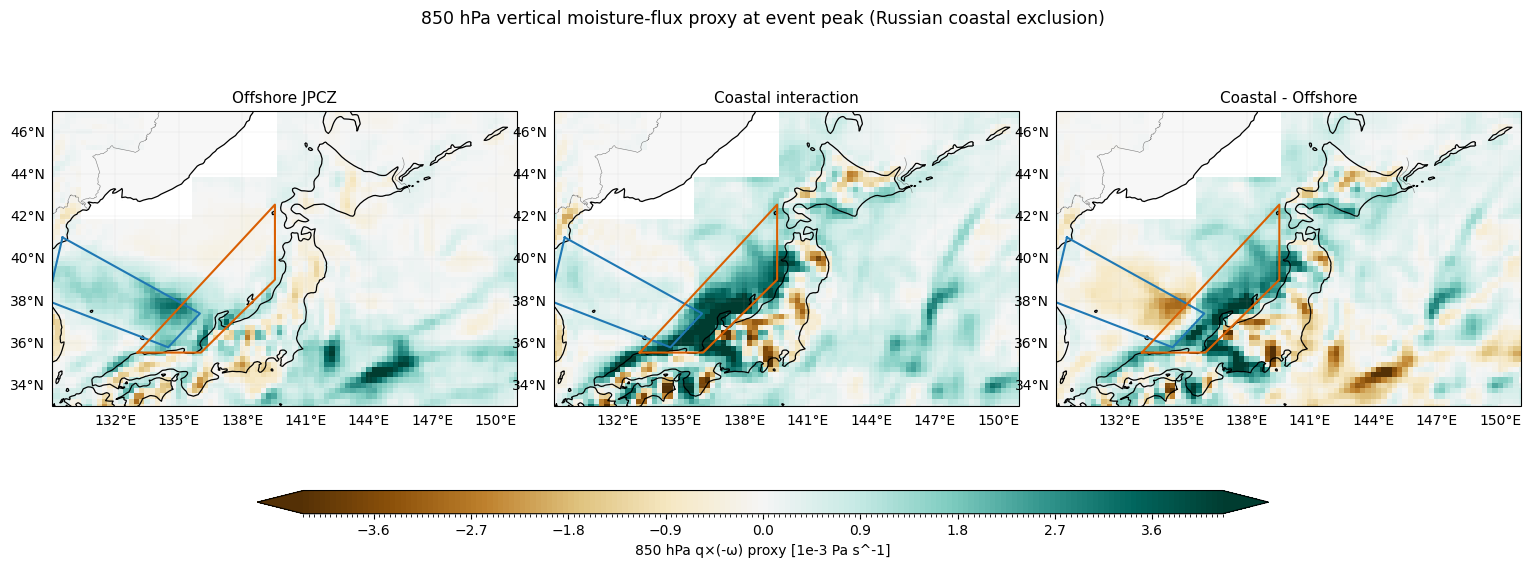

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_vertical_moisture_flux_proxy_850_peak_regime_triptych.png


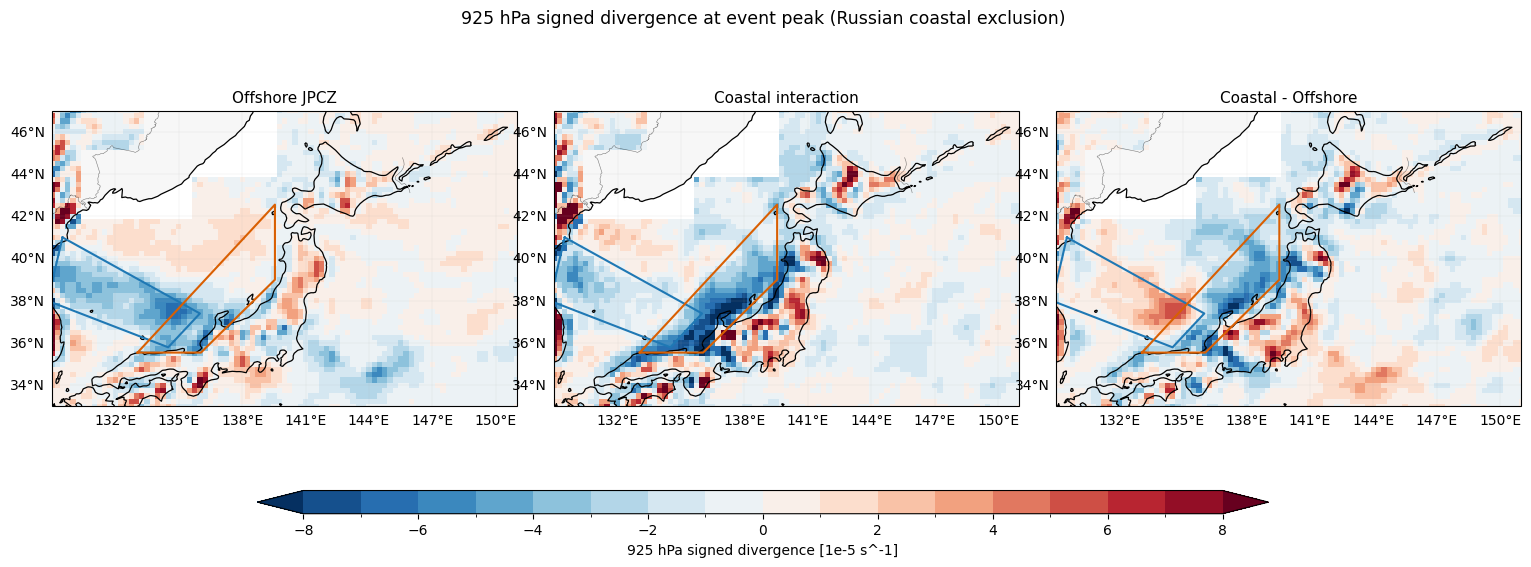

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_divergence_925_peak_regime_triptych.png
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_plot_level_summary.csv
Selected display ranges for Notebook 22 objective-group composites


,field,data_min,data_max,level_min,level_max,level_step,n_bins
0,vertical_moisture_flux_proxy_850_peak,-5.557569,7.228603,-4.25,4.25,0.05,170
1,divergence_925_peak,-14.825309,30.554710,-8.00,8.00,1.00,16



Saved Notebook 22 objective-group composite plots


,plot_kind,field,local_path,drive_path
0,objective_regime_triptych,vertical_moisture_flux_proxy_850_peak,outputs/verification/objective_coastal_box_reg...,/content/drive/MyDrive/JPCZcatalog_outputs/obj...
1,objective_regime_triptych,divergence_925_peak,outputs/verification/objective_coastal_box_reg...,/content/drive/MyDrive/JPCZcatalog_outputs/obj...


In [9]:
required_globals = [
    "offshore_ds",
    "coastal_ds",
    "diff_ds",
    "plot_regime_triptych",
    "build_composite_levels",
    "summarize_level_range",
    "maybe_copy_to_drive",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 22 objective-group composite cell before the composite plotting cell. "
        f"Missing globals: {missing_globals}"
    )

plot_level_rows = []
plot_inventory_rows = []

for field_name in COMPOSITE_FIELDS:
    levels = build_composite_levels(field_name, offshore_ds[field_name], coastal_ds[field_name], diff_ds[field_name])
    plot_level_rows.append(
        summarize_level_range(field_name, offshore_ds[field_name], coastal_ds[field_name], diff_ds[field_name], levels)
    )
    fig = plot_regime_triptych(offshore_ds, coastal_ds, diff_ds, field_name, PLOT_DOMAIN, levels=levels)
    plot_path = PLOT_DIR / f"objective_coastal_box_{field_name}_regime_triptych.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.show()
    maybe_copy_to_drive(plot_path)
    plot_inventory_rows.append({
        "plot_kind": "objective_regime_triptych",
        "field": field_name,
        "local_path": str(plot_path),
        "drive_path": str(Path(DRIVE_OUTPUT_DIR) / plot_path.name),
    })

plot_level_summary_df = pd.DataFrame(plot_level_rows)
plot_level_summary_df.to_csv(PLOT_LEVEL_SUMMARY_PATH, index=False)
maybe_copy_to_drive(PLOT_LEVEL_SUMMARY_PATH)
plot_inventory_df = pd.DataFrame(plot_inventory_rows)
plot_inventory_df.to_csv(PLOT_INVENTORY_PATH, mode="a", index=False, header=not PLOT_INVENTORY_PATH.exists())
print("Selected display ranges for Notebook 22 objective-group composites")
display(plot_level_summary_df)
print("\nSaved Notebook 22 objective-group composite plots")
display(plot_inventory_df)


In [10]:
required_globals = [
    "threshold_summary_df",
    "threshold_sensitivity_display_df",
    "quartile_reference_df",
    "label_count_summary_df",
    "objective_vs_k2_counts_df",
    "objective_vs_k3_counts_df",
    "group_box_summary_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 22 earlier cells before the summary cell. "
        f"Missing globals: {missing_globals}"
    )

print("Notebook 22 summary")
print("- This notebook follows the simplified method: coastal strip plus JPCZ polygon, moisture flux plus divergence.")
print("- The main downstream result now uses Calculation B, where the full JPCZ polygon keeps the overlap and the coastal wedge removes it.")
print("- Calculation A tests what changes when the overlap is removed from the polygon only.")
print("- Calculation C remains the full-overlap sensitivity check.")
print("- The Calculation C / comparison cell above shows how much the 201-event split changes across all three treatments.")
print("- The tables below show both where the active thresholds came from and how the event counts change when the thresholds are tweaked.")
print("\nThreshold origin table (quartiles plus active threshold)")
display(threshold_summary_df)
print("\nThreshold sweep table for the active scheme")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(threshold_sensitivity_display_df)
print("\nQuartile reference table")
display(quartile_reference_df)
print("\nObjective regime counts")
display(label_count_summary_df)
print("\nKey polygon and coastal-strip means for the objective groups")
display(group_box_summary_df)
print("\nReference overlap with cleaned k=2 (secondary diagnostic only)")
display(objective_vs_k2_counts_df)
print("\nReference overlap with cleaned k=3 (secondary diagnostic only)")
display(objective_vs_k3_counts_df)
print("\nHow to read the two regimes")
print("- offshore_jpcz_core = coastal-strip moisture flux stays below the tested split while polygon moisture flux and polygon convergence support the JPCZ")
print("- coastal_interaction = coastal-strip moisture flux is large enough, with coastal convergence support")
print("- mixed_transition = both conditions are true in the same event")
print("- weak_or_unclear = neither regime is strongly identified by the tested threshold set")
print("- Notebook 23 should now manually verify these labels and timestamp event evolution")


Notebook 22 summary
- This notebook follows the simplified method: coastal strip plus JPCZ polygon, moisture flux plus divergence.
- The main downstream result now uses Calculation B, where the full JPCZ polygon keeps the overlap and the coastal wedge removes it.
- Calculation A tests what changes when the overlap is removed from the polygon only.
- Calculation C remains the full-overlap sensitivity check.
- The Calculation C / comparison cell above shows how much the 201-event split changes across all three treatments.
- The tables below show both where the active thresholds came from and how the event counts change when the thresholds are tweaked.

Threshold origin table (quartiles plus active threshold)


,threshold_key,metric,metric_label,units,q25,median,q75,default_quantile,default_threshold_value,threshold_source,tested_quantiles,tested_threshold_values,rule_role
0,polygon_qflux_min,polygon_qflux_850_mean,JPCZ polygon mean 850 hPa q×(-ω),1e-3 Pa s^-1,0.443535,0.591391,0.921394,0.60,0.684752,seeded from q=0.60,"0.55, 0.60, 0.65, 0.70","0.648, 0.685, 0.751, 0.868",minimum JPCZ polygon moisture-flux support for...
1,coastal_qflux_split,coastal_qflux_850_mean,Coastal wedge minus JPCZ overlap mean 850 hPa ...,1e-3 Pa s^-1,0.494673,0.914214,1.617480,0.75,1.617480,seeded from q=0.75,"0.60, 0.65, 0.70, 0.75, 0.80","1.061, 1.185, 1.346, 1.617, 1.857",Coastal wedge minus JPCZ overlap moisture-flux...
2,polygon_div_max,polygon_div_925_mean,JPCZ polygon mean 925 hPa divergence,1e-5 s^-1,-2.626144,-2.120996,-1.639784,0.25,-2.626144,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-2.749, -2.626, -2.532, -2.369",maximum JPCZ polygon divergence allowed for of...
3,coastal_div_max,coastal_div_925_mean,Coastal wedge minus JPCZ overlap mean 925 hPa ...,1e-5 s^-1,-3.129825,-1.889082,-0.719244,0.25,-3.129825,seeded from q=0.25,"0.20, 0.25, 0.30, 0.35","-3.366, -3.130, -2.950, -2.728",maximum Coastal wedge minus JPCZ overlap diver...



Threshold sweep table for the active scheme


,default_setting,polygon_qflux_q,polygon_qflux_min [1e-3 Pa s^-1],coastal_qflux_q,coastal_qflux_split [1e-3 Pa s^-1],polygon_div_q,polygon_div_max [1e-5 s^-1],coastal_div_q,coastal_div_max [1e-5 s^-1],offshore_n,coastal_n,mixed_n,weak_n,sorted_n,sorted_fraction,labels_summary
0,True,0.60,0.684752,0.75,1.617480,0.25,-2.626144,0.25,-3.129825,31,33,0,137,64,0.318,31 offshore | 33 coastal | 0 mixed | 137 weak
1,False,0.55,0.647563,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,29,56,0,116,85,0.423,29 offshore | 56 coastal | 0 mixed | 116 weak
2,False,0.60,0.684752,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,27,56,0,118,83,0.413,27 offshore | 56 coastal | 0 mixed | 118 weak
3,False,0.55,0.647563,0.65,1.184638,0.35,-2.368891,0.35,-2.727745,31,52,0,118,83,0.413,31 offshore | 52 coastal | 0 mixed | 118 weak
4,False,0.55,0.647563,0.60,1.061034,0.30,-2.532481,0.35,-2.727745,26,56,0,119,82,0.408,26 offshore | 56 coastal | 0 mixed | 119 weak
5,False,0.55,0.647563,0.60,1.061034,0.25,-2.626144,0.35,-2.727745,25,56,0,120,81,0.403,25 offshore | 56 coastal | 0 mixed | 120 weak
6,False,0.60,0.684752,0.60,1.061034,0.30,-2.532481,0.35,-2.727745,25,56,0,120,81,0.403,25 offshore | 56 coastal | 0 mixed | 120 weak
7,False,0.65,0.750528,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,25,56,0,120,81,0.403,25 offshore | 56 coastal | 0 mixed | 120 weak
8,False,0.60,0.684752,0.65,1.184638,0.35,-2.368891,0.35,-2.727745,29,52,0,120,81,0.403,29 offshore | 52 coastal | 0 mixed | 120 weak
9,False,0.55,0.647563,0.70,1.345528,0.35,-2.368891,0.35,-2.727745,34,47,0,120,81,0.403,34 offshore | 47 coastal | 0 mixed | 120 weak



Quartile reference table


...


Reference overlap with cleaned k=2 (secondary diagnostic only)


cleaned_cluster_ward_2,1,2
objective_regime_label,,
coastal_interaction,27,6
offshore_jpcz_core,31,0
weak_or_unclear,122,15



Reference overlap with cleaned k=3 (secondary diagnostic only)


cleaned_cluster_ward_3,1,2,3
objective_regime_label,,,
coastal_interaction,8,6,19
offshore_jpcz_core,18,0,13
weak_or_unclear,78,15,44



How to read the two regimes
- offshore_jpcz_core = coastal-strip moisture flux stays below the tested split while polygon moisture flux and polygon convergence support the JPCZ
- coastal_interaction = coastal-strip moisture flux is large enough, with coastal convergence support
- mixed_transition = both conditions are true in the same event
- weak_or_unclear = neither regime is strongly identified by the tested threshold set
- Notebook 23 should now manually verify these labels and timestamp event evolution
